In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
# Load the dataset
df = pd.read_csv("boston_housing.csv")

In [4]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [6]:
df[["RM", "MEDV"]].head()

,RM,MEDV
0,6.575,24.0
1,6.421,21.6
2,7.185,34.7
3,6.998,33.4
4,7.147,36.2


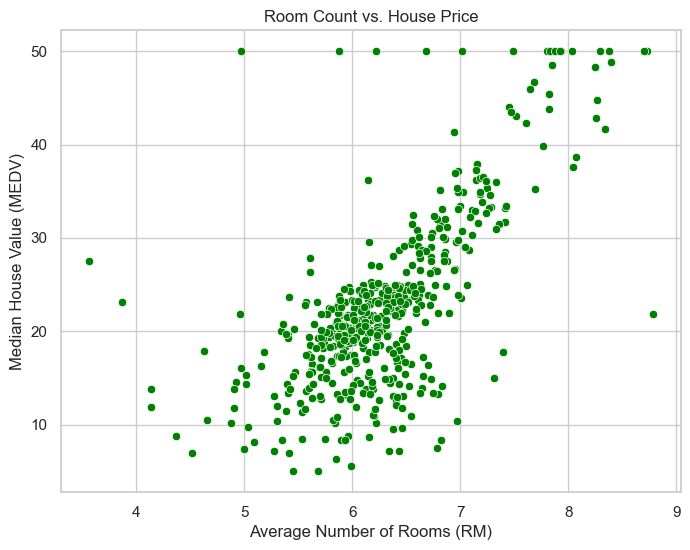

In [8]:

sns.set_theme(style='whitegrid')
plt.figure(figsize=(8,6))
sns.scatterplot(x='RM', y='MEDV', data=df, color='green')
plt.title('Room Count vs. House Price')
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('Median House Value (MEDV)')
plt.show()


In [12]:
from sklearn.linear_model import LinearRegression
import numpy as np
X = df[['RM']].values
y = np.asarray(df['MEDV'])

model = LinearRegression()

model.fit(X, y)
print(f"Intercept: {model.intercept_:.2f}")
print(f"Slope: {model.coef_[0]:.2f}")

Intercept: -34.67
Slope: 9.10


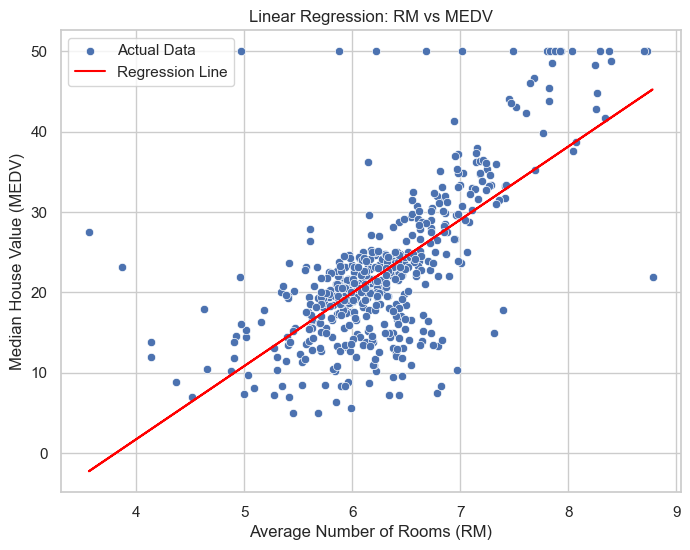

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X.flatten(), y=y, label='Actual Data')
plt.plot(X, model.predict(X), color='red', label='Regression Line')
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('Median House Value (MEDV)')
plt.title('Linear Regression: RM vs MEDV')
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X)

mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

# The regression model using only the number of rooms (RM)
# predicts house prices with a mean absolute error (MAE) of $4,450
# and a root mean squared error (RMSE) of $6,600, indicating the average
# prediction deviates from the actual price by that amount. The model explains
# approximately 48% of the variance in house prices, as shown by the R² score of
# 0.48, which is a moderate fit. While these results are reasonable for a single-feature
# model, they suggest that incorporating more features could significantly improve prediction accuracy

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


MAE: 4.45
MSE: 43.60
RMSE: 6.60
R² Score: 0.48
